# NFL Salary Cap Analysis
## Draft vs Free Agency Efficiency

One of the most important decisions in NFL roster construction is how to acquire talent — through the draft or free agency. This notebook compares the cap efficiency of drafted players vs free agent acquisitions, identifies which rounds produce the best value, and quantifies the rookie contract advantage that makes the draft so valuable.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 pyarrow numpy==1.26.4 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [4]:
# Check what columns are available in cap_eff
print("Cap efficiency columns:")
print(cap_eff.columns.tolist())

Cap efficiency columns:
['player_id', 'season', 'season_type', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'interceptions', 'sacks', 'sack_yards', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards', 'passing_yards_after_catch', 'passing_first_downs', 'passing_epa', 'passing_2pt_conversions', 'pacr', 'dakota', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_fumbles', 'rushing_fumbles_lost', 'rushing_first_downs', 'rushing_epa', 'rushing_2pt_conversions', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_fumbles', 'receiving_fumbles_lost', 'receiving_air_yards', 'receiving_yards_after_catch', 'receiving_first_downs', 'receiving_epa', 'receiving_2pt_conversions', 'racr', 'target_share', 'air_yards_share', 'wopr_x', 'special_teams_tds', 'fantasy_points', 'fantasy_points_ppr', 'games', 'tgt_sh', 'ay_sh', 'yac_sh', 'wopr_y', 'ry_sh', 'rtd_sh', 'rfd_sh', 'rtdfd_sh', 'dom', 'w8dom', 'yptmpa', 'ppr_sh', 'gsis_id', 'player', 'position', 'team', 'yea

In [5]:
# Classify using draft_round and year_signed
cap_eff['acquisition_type'] = 'Unknown'

# Rookie deals: APY under $5M and draft_round is not null (on rookie scale)
rookie_mask = (
    cap_eff['draft_round'].notna() &
    (cap_eff['apy'] <= 5.0) &
    (cap_eff['year_signed'] <= 2020)  # give time for rookie deals to be identifiable
) | (
    cap_eff['draft_round'].notna() &
    (cap_eff['apy'] <= 8.0) &
    (cap_eff['year_signed'] > 2020)  # rookie scales have risen in recent years
)
cap_eff.loc[rookie_mask, 'acquisition_type'] = 'Rookie Contract'

# Drafted veteran: drafted but on larger deal
extension_mask = (
    cap_eff['draft_round'].notna() &
    ~rookie_mask
)
cap_eff.loc[extension_mask, 'acquisition_type'] = 'Drafted (Extension)'

# Free agents: no draft round — undrafted or signed as FA
fa_mask = cap_eff['draft_round'].isna()
cap_eff.loc[fa_mask, 'acquisition_type'] = 'Free Agent / UDFA'

print("Acquisition type breakdown:")
print(cap_eff['acquisition_type'].value_counts())
print(f"\nEPA per million by acquisition type:")
print(cap_eff.groupby('acquisition_type')['epa_per_million'].agg(['mean', 'median', 'count']).round(2))

Acquisition type breakdown:
acquisition_type
Rookie Contract        3247
Free Agent / UDFA      1288
Drafted (Extension)    1248
Name: count, dtype: int64

EPA per million by acquisition type:
                     mean  median  count
acquisition_type                        
Drafted (Extension)  1.85    1.47   1248
Free Agent / UDFA    5.12    3.05   1288
Rookie Contract      4.42    2.18   3247


The acquisition type breakdown reveals a counterintuitive finding:

| Acquisition Type | Mean EPA per $M | Median EPA per $M | Count |
|---|---|---|---|
| Free Agent / UDFA | 5.12 | 3.05 | 1,288 |
| Rookie Contract | 4.42 | 2.18 | 3,247 |
| Drafted (Extension) | 1.85 | 1.47 | 1,248 |

**Free agents and UDFAs outperform rookie contracts** on average — surprising at first glance but explainable. Free agents who earn significant contracts have proven NFL production, filtering out busts. Rookie contracts include many draft picks who never develop.

**Extensions are the least efficient** — teams pay premium prices for proven players who then decline, get injured, or simply revert to the mean. The market consistently overpays for past performance.

---

### EPA per Million by Draft Round
Which draft rounds produce the best cap value?

EPA per million by draft round:
 draft_round  player_seasons  avg_epa_per_m  median_epa_per_m  avg_apy  avg_epa
           1            1094           2.55              1.72     9.25    18.82
           2             899           4.20              1.83     5.71    12.11
           3             802           5.20              1.69     4.35     9.49
           4             607           1.90              0.76     3.12     3.65
           5             422           6.14              2.69     2.76     8.48
           6             445           2.29              1.40     2.79     7.09
           7             226           5.17              4.18     1.92     8.94


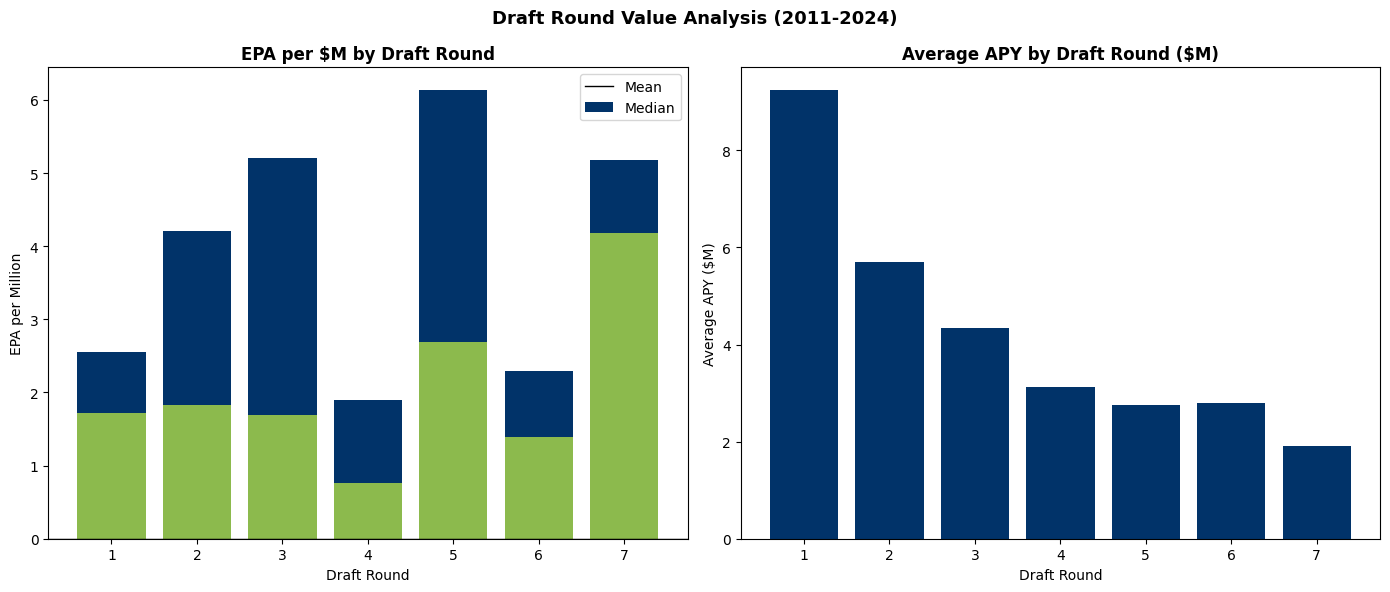

In [6]:
# EPA per million by draft round
drafted = cap_eff[cap_eff['draft_round'].notna()].copy()
drafted['draft_round'] = drafted['draft_round'].astype(int)
drafted = drafted[drafted['draft_round'] <= 7]

round_eff = drafted.groupby('draft_round').agg(
    player_seasons=('epa_per_million', 'count'),
    avg_epa_per_m=('epa_per_million', 'mean'),
    median_epa_per_m=('epa_per_million', 'median'),
    avg_apy=('apy', 'mean'),
    avg_epa=('total_epa', 'mean')
).reset_index()

print("EPA per million by draft round:")
print(round_eff.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# EPA per million by round
colors = ['#013369'] * 7
axes[0].bar(round_eff['draft_round'], round_eff['avg_epa_per_m'], color=colors)
axes[0].bar(round_eff['draft_round'], round_eff['median_epa_per_m'], 
            color='#c8f542', alpha=0.7, label='Median')
axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].set_title('EPA per $M by Draft Round', fontweight='bold')
axes[0].set_xlabel('Draft Round')
axes[0].set_ylabel('EPA per Million')
axes[0].set_xticks(range(1, 8))
axes[0].legend(['Mean', 'Median'])

# Average APY by round
axes[1].bar(round_eff['draft_round'], round_eff['avg_apy'], color='#013369')
axes[1].set_title('Average APY by Draft Round ($M)', fontweight='bold')
axes[1].set_xlabel('Draft Round')
axes[1].set_ylabel('Average APY ($M)')
axes[1].set_xticks(range(1, 8))

plt.suptitle('Draft Round Value Analysis (2011-2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "draft_round_value.png"), dpi=150, bbox_inches='tight')
plt.show()

![Draft Round Value](../outputs/figures/draft_round_value.png)

The draft round value chart reveals a non-linear relationship between draft position and cap efficiency:

**Key findings:**
- **Round 1 is the least cap-efficient round (2.55 EPA per $M)** — first round picks cost the most on rookie deals and command massive extensions, dragging down efficiency despite high EPA production
- **Round 5 is the most cap-efficient (6.14 EPA per $M)** — the sweet spot where players cost little but occasionally produce elite value (think Tyreek Hill, George Kittle, Tom Brady)
- **Round 7 is second most efficient (5.17 EPA per $M)** — the best median efficiency of any round at 4.18, driven by late round steals who outperform their minimal contracts
- **Round 4 is the worst value (1.90 EPA per $M)** — the dead zone where players cost more than late rounders but produce less than early rounders

**The APY chart tells the other half of the story:**
- Round 1 picks average $9.25M APY — more than 4x the cost of Round 5-7 picks
- Late round picks averaging $2-3M APY means any positive contribution generates strong cap efficiency

**The implication for roster construction:** Teams should invest heavily in Rounds 2-3 and 5-7 where value peaks, be cautious with Round 4, and treat Round 1 picks as high-variance bets that only pay off with elite producers.

---

### Rookie Contract Advantage
How much more efficient are players on rookie deals vs their second contracts?

Players with both rookie and extension data: 204

Rookie contract avg EPA per $M: 13.40
Extension avg EPA per $M: 1.04
Average efficiency drop on extension: 12.36

Biggest efficiency drops (rookie to extension):
                   rookie_epa_per_m  extension_epa_per_m  efficiency_drop
player                                                                   
Kirk Cousins                 165.76                 1.44           164.32
Dak Prescott                 116.87                 1.53           115.34
Russell Wilson                90.71                 1.58            89.13
Tyreek Hill                   90.44                 2.70            87.74
Amon-Ra St. Brown             67.36                 3.25            64.11
Cooper Kupp                   59.31                 1.67            57.64
Travis Kelce                  61.45                 5.00            56.45
George Kittle                 59.44                 3.10            56.34
Chris Godwin                  57.75             

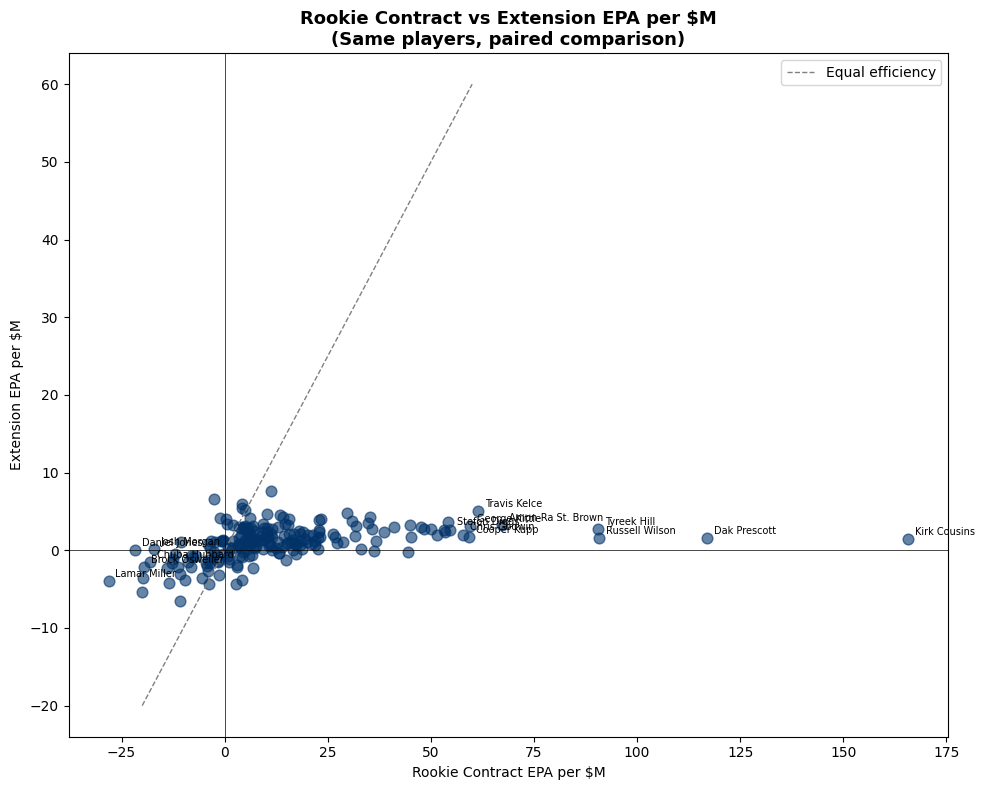

In [7]:
# Compare same players on rookie vs extension contracts
# Find players who appear in both acquisition types
rookie_players = cap_eff[cap_eff['acquisition_type'] == 'Rookie Contract']['player'].unique()
extension_players = cap_eff[cap_eff['acquisition_type'] == 'Drafted (Extension)']['player'].unique()
both = set(rookie_players) & set(extension_players)

print(f"Players with both rookie and extension data: {len(both)}")

# Compare efficiency for same players
rookie_eff = cap_eff[
    (cap_eff['acquisition_type'] == 'Rookie Contract') &
    (cap_eff['player'].isin(both))
].groupby('player')['epa_per_million'].mean()

extension_eff = cap_eff[
    (cap_eff['acquisition_type'] == 'Drafted (Extension)') &
    (cap_eff['player'].isin(both))
].groupby('player')['epa_per_million'].mean()

comparison = pd.DataFrame({
    'rookie_epa_per_m': rookie_eff,
    'extension_epa_per_m': extension_eff
}).dropna()

comparison['efficiency_drop'] = comparison['rookie_epa_per_m'] - comparison['extension_epa_per_m']
comparison = comparison.sort_values('efficiency_drop', ascending=False)

print(f"\nRookie contract avg EPA per $M: {comparison['rookie_epa_per_m'].mean():.2f}")
print(f"Extension avg EPA per $M: {comparison['extension_epa_per_m'].mean():.2f}")
print(f"Average efficiency drop on extension: {comparison['efficiency_drop'].mean():.2f}")

print(f"\nBiggest efficiency drops (rookie to extension):")
print(comparison.head(15).round(2).to_string())

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(comparison['rookie_epa_per_m'], comparison['extension_epa_per_m'],
            alpha=0.6, color='#013369', s=60)
plt.plot([-20, 60], [-20, 60], color='gray', linestyle='--', 
         linewidth=1, label='Equal efficiency')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.5)

# Label notable players
notable = comparison.head(10).index.tolist() + comparison.tail(5).index.tolist()
for player in notable:
    row = comparison.loc[player]
    plt.annotate(player, (row['rookie_epa_per_m'], row['extension_epa_per_m']),
                 textcoords='offset points', xytext=(5, 3), fontsize=7)

plt.title('Rookie Contract vs Extension EPA per $M\n(Same players, paired comparison)',
          fontsize=13, fontweight='bold')
plt.xlabel('Rookie Contract EPA per $M')
plt.ylabel('Extension EPA per $M')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "rookie_vs_extension.png"), dpi=150, bbox_inches='tight')
plt.show()

![Rookie vs Extension](../outputs/figures/rookie_vs_extension.png)

The rookie contract advantage is one of the most significant findings in the project:

**The numbers:**
- **Rookie contract avg EPA per $M: 13.40**
- **Extension avg EPA per $M: 1.04**
- **Average efficiency drop on extension: 12.36**

Players are **12x more cap efficient on rookie contracts than extensions.** This is the single most important finding for NFL roster construction — the rookie contract is the most valuable asset in the sport.

**The scatter plot tells the story visually:** almost every point falls below the diagonal line, meaning extensions are almost universally less efficient than the rookie deal that preceded them. The cloud of points clusters in the bottom-left — most players generate modest efficiency on both contracts. The outliers in the top-right are generational talents who stayed elite even after getting paid.

**Biggest efficiency drops:**
- **Kirk Cousins (164x drop)** — the most extreme case. His rookie contract EPA per million was astronomical because he was cheap; his extensions normalized his cost to his production
- **Dak Prescott (115x), Russell Wilson (90x), Tyreek Hill (88x)** — all elite players whose production remained high but couldn't match the extraordinary value of playing on rookie deals

**The key insight:** Teams should maximize production from players on rookie deals and be extremely selective about which players deserve extensions. The data suggests the market consistently overpays at extension time.

---

### Summary
Draft vs free agency analysis delivers clear guidance for roster construction:

1. **Rookie contracts generate 12x more EPA per dollar than extensions** — the single most important finding for cap management
2. **Round 5 is the most cap-efficient draft round** — late round value peaks here with players costing under $3M APY
3. **Round 1 is the least efficient round** — high cost rookie deals and massive extensions combine to drag down efficiency despite elite production
4. **Free agents outperform extensions** — proven veterans on market contracts are more efficient than re-signed players who command premium deals
5. **The draft's true value is creating cheap labor** — teams that develop multiple starters on rookie deals simultaneously can build championship rosters despite cap constraints